# Лабораторная работа 2. Обучение с учителем. Задача регрессии

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from math import sqrt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

### Загрузка данных

In [2]:
data = pd.read_csv('../data/final_data_diamonds.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)

### Первый шаг: выделение целевого признака и предикторов

In [3]:
y = data["price"]
X = data.drop(["price"], axis=1)
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64

In [4]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,0.373383,0.346954,0.290021


### Второй шаг: разделение данных на обучающую и тестовую выборки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((43152, 9), (43152,), (10788, 9), (10788,))

Итак, данные предобработаны, целевой признак выделен, имеются обучающая и тестовая выборка. Мы готовы приступить к обучению.

### Линейная регрессия (Linear Regression). Постановка задачи

In [7]:
lr = LinearRegression().fit(X_train, y_train)
lr.predict(X_test)

array([ -705.47195673, 14502.96316947, -1332.34810147, ...,
        -216.27593362,  2529.83999448,   532.95417621], shape=(10788,))

In [8]:
y_pred = lr.predict(X_test)

In [9]:
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')

MAE: 809.98
MSE: 1470746.35
RMSE: 1212.74
MAPE: 0.66
R^2: 0.91


In [10]:
len(lr.coef_)
lr.coef_

array([ 5224.13895827,   127.06047361,   323.10538045,   501.22298438,
        -112.60580933,   -52.7875147 , -1638.46444118,   617.24415689,
         -66.33493526])

In [11]:
# L1
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 810.02
MSE: 1470731.90
RMSE: 1212.74
MAPE: 0.66
R^2: 0.91


array([ 5222.47675229,   127.036995  ,   323.08435012,   501.25190318,
        -112.48553868,   -52.82172569, -1632.0707417 ,   612.98240664,
         -66.82959334])

In [12]:
# L2
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 810.48
MSE: 1471726.80
RMSE: 1213.15
MAPE: 0.66
R^2: 0.91


array([ 5205.88292044,   125.99780849,   322.77302975,   501.81079103,
        -115.7890499 ,   -54.08759874, -1450.15771653,   419.9706583 ,
         -38.89987366])

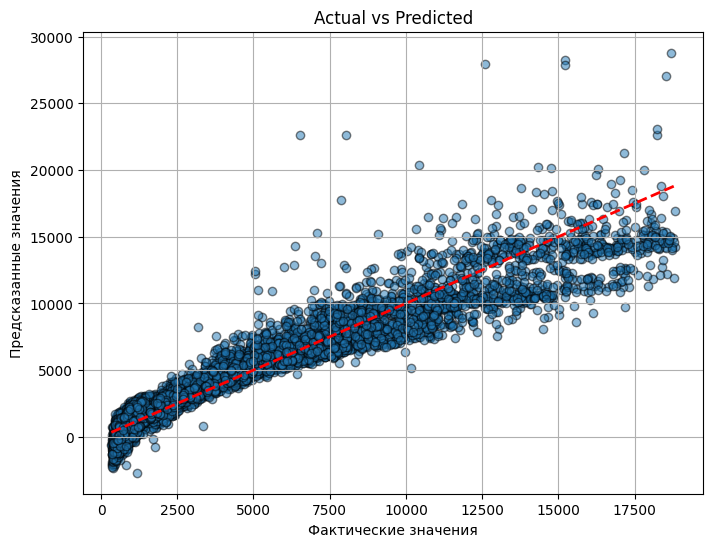

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

In [14]:
parameters = {'alpha': np.arange(0, 1, 0.1)}    

In [15]:
ridge_optimal = GridSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [16]:
ridge_optimal = RandomizedSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [17]:
ridge_final = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)

In [18]:
# L1
ridge = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 810.05
MSE: 1470720.51
RMSE: 1212.73
MAPE: 0.66
R^2: 0.91


array([ 5221.14899515,   127.01840831,   323.06752599,   501.27490173,
        -112.38949193,   -52.84872282, -1626.99199402,   609.60455763,
         -67.22274149])

In [19]:
# L2
lasso = Lasso(alpha=0.9).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 810.92
MSE: 1472688.70
RMSE: 1213.54
MAPE: 0.66
R^2: 0.91


array([ 5191.31678543,   125.14815516,   322.50725074,   502.27979278,
        -118.34836698,   -55.12673169, -1299.70120386,   262.21159906,
         -16.86163176])

In [20]:
pf = PolynomialFeatures(2)
X_p=pf.fit_transform(X)
X_p

array([[ 1.00000000e+00, -1.19934143e+00,  4.00000000e+00, ...,
         2.47550480e+00,  2.50737600e+00,  2.53965753e+00],
       [ 1.00000000e+00, -1.24158203e+00,  3.00000000e+00, ...,
         2.88660983e+00,  3.00074203e+00,  3.11938685e+00],
       [ 1.00000000e+00, -1.19934143e+00,  1.00000000e+00, ...,
         2.22789058e+00,  2.63621937e+00,  3.11938685e+00],
       ...,
       [ 1.00000000e+00, -2.06687922e-01,  2.00000000e+00, ...,
         2.29249248e-03, -1.49376981e-03,  9.73328494e-04],
       [ 1.00000000e+00,  1.31236743e-01,  3.00000000e+00, ...,
         1.20376925e-01,  1.00623740e-01,  8.41119426e-02],
       [ 1.00000000e+00, -1.01086456e-01,  4.00000000e+00, ...,
         1.50347914e-02,  1.79302707e-02,  2.13833767e-02]],
      shape=(53940, 55))

In [24]:
lr2 = LinearRegression().fit(X_p, y)
lr2.coef_

array([ 2.22312413e-13,  2.23051081e+03, -2.01114007e+01,  9.65129339e+01,
        1.53678002e+02, -1.62863121e+02, -4.04496404e+00, -5.83002895e+02,
       -9.94456418e+02,  3.66290157e+02, -6.59255459e+02,  3.48101136e+02,
        2.09154773e+02,  6.43984215e+02,  9.30448753e+00,  9.93612195e+01,
       -1.85381838e+03,  1.73107574e+03,  1.37600562e+03,  4.21541109e+00,
        1.90729789e+01,  1.74828467e+00, -3.37284814e+01, -1.09939120e+01,
       -6.86829314e+02,  1.57448288e+02,  2.85499536e+02, -2.71399845e+01,
        1.20523171e+02,  2.81261792e+01,  4.56921073e+00, -5.88072338e+01,
        3.38638332e+02, -1.24000540e+02, -2.97934927e+00, -2.88007258e+00,
       -1.56910996e+01,  3.77841464e+02, -4.01672909e+02, -5.74765611e+01,
       -2.74109784e+01, -1.81845757e+01,  8.00978278e+01,  1.15765578e+02,
       -7.32787827e+01, -1.51809089e+01,  4.20890674e+02, -6.66966063e+02,
        1.38861227e+02, -1.74155018e+03,  2.67768070e+03,  1.04438975e+03,
        1.34077916e+03, -

In [25]:
X_d = X
y_d = lr2.coef_[0][2] + lr2.coef_[0][1]*X_d + lr2.coef_[0][0]*X_d**2
y_d

IndexError: invalid index to scalar variable.

ValueError: x and y must be the same size

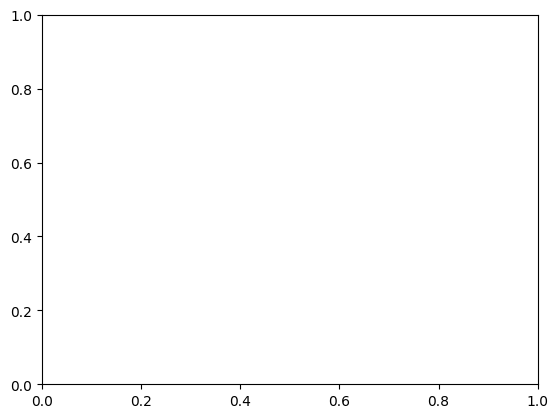

In [26]:
plt.scatter(X, y, label='Истинные значения');
plt.plot(X, lr.predict(X), label='Предсказанные значения (линейная регрессия)');
plt.scatter(X, lr2.predict(X_p), label='Предсказанные значения (полиномиальная регрессия)');
plt.legend()